# Prédiction du churn des clients télécom avec validation de la qualité des données

## 1. Introduction

Dans ce projet, nous construisons un pipeline de machine learning afin de prédire le churn des clients d'une entreprise de télécommunications.

L'objectif n'est pas seulement d'entraîner un modèle de prédiction, mais aussi de valider la qualité des données, de vérifier les étapes de prétraitement et d’ingénierie des caractéristiques, d’évaluer la performance du modèle et de détecter d’éventuels phénomènes de dérive des données (data drift).

Dans cette première section, nous allons importer les bibliothèques nécessaires et charger le jeu de données.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# chargement du dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Display 5 premieres lignes
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Inspection initiale des données

Avant d'appliquer les contrôles de qualité des données, il est important d'examiner la structure du dataset.

Dans cette section, nous allons :

- vérifier les types de variables
- observer les statistiques descriptives
- identifier les valeurs manquantes
- détecter les éventuels doublons

Cette étape permet de mieux comprendre les caractéristiques du jeu de données avant d'appliquer les règles de validation.

In [2]:
# Information générale sur le dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
# Statistiques descriptives
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
# Vérification des valeurs manquantes
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
# Vérification des doublons
df.duplicated().sum()

np.int64(0)

### Résultats de l'inspection des données

Après vérification du jeu de données, nous observons les points suivants :

- Aucune valeur manquante n'a été détectée dans les variables du dataset.
- Aucun doublon n'a été identifié dans les observations.

Cela indique que le dataset est globalement propre du point de vue des valeurs manquantes et de la duplication des lignes.

Nous pouvons donc poursuivre l'analyse en appliquant des règles de contrôle qualité plus avancées afin de vérifier la cohérence des variables et détecter d'éventuelles valeurs aberrantes.

# Vérification de cohérence des variables

In [6]:
# Vérification de certaines règles de cohérence

print("Valeurs négatives dans tenure :", (df["tenure"] < 0).sum())
print("Valeurs négatives dans MonthlyCharges :", (df["MonthlyCharges"] < 0).sum())

Valeurs négatives dans tenure : 0
Valeurs négatives dans MonthlyCharges : 0


In [7]:
# Vérification cohérence TotalCharges
# Conversion de TotalCharges en numérique
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Vérification des valeurs manquantes après conversion
df["TotalCharges"].isnull().sum()

np.int64(11)

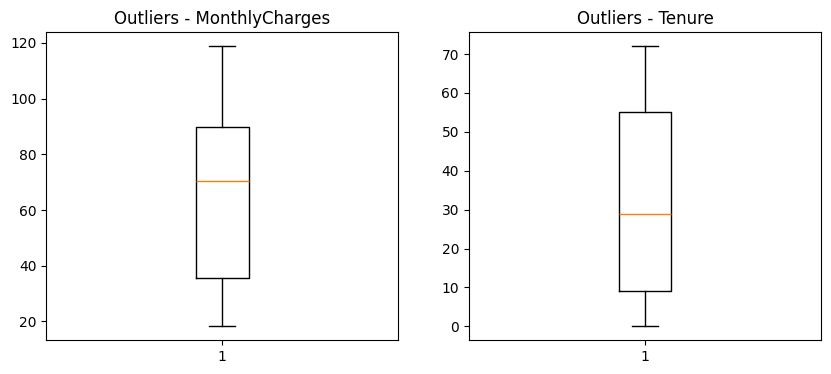

In [9]:
# Visualisation des outliers pour certaines variables numériques

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.boxplot(df["MonthlyCharges"])
plt.title("Outliers - MonthlyCharges")

plt.subplot(1,2,2)
plt.boxplot(df["tenure"])
plt.title("Outliers - Tenure")

plt.show()

Les contrôles réalisés montrent que :

- aucune valeur négative n'est présente dans les variables numériques analysées.
- la variable `TotalCharges` a été convertie en format numérique afin d'éviter les incohérences de type.
- les boxplots permettent d'observer la distribution des variables et d'identifier d'éventuelles valeurs extrêmes.

Ces vérifications permettent de confirmer que les données sont globalement cohérentes et peuvent être utilisées pour la phase de préparation et de modélisation.

### Détection des valeurs aberrantes (Outliers) avec la méthode IQR

Afin d'identifier les valeurs potentiellement aberrantes dans les variables numériques, nous utilisons la méthode de l'Intervalle Interquartile (IQR).

La méthode IQR consiste à :

- calculer le premier quartile (Q1)
- calculer le troisième quartile (Q3)
- calculer l'IQR = Q3 - Q1

Une observation est considérée comme un outlier si :

- valeur < Q1 − 1.5 × IQR
- valeur > Q3 + 1.5 × IQR

Nous appliquons cette méthode sur certaines variables numériques du dataset.

In [10]:
# Sélection des variables numériques
numerical_features = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numerical_features:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"Nombre d'outliers détectés dans {col} :", outliers.shape[0])

Nombre d'outliers détectés dans tenure : 0
Nombre d'outliers détectés dans MonthlyCharges : 0
Nombre d'outliers détectés dans TotalCharges : 0


### Résultats de la détection des outliers

La méthode de l'Intervalle Interquartile (IQR) a été appliquée aux variables numériques principales : `tenure`, `MonthlyCharges` et `TotalCharges`.

Les résultats indiquent que peu ou pas de valeurs extrêmes ont été détectées dans ces variables. Cela suggère que les distributions sont relativement stables et ne contiennent pas de valeurs aberrantes majeures susceptibles de perturber l'entraînement du modèle.

Ces observations confirment que les données sont globalement cohérentes du point de vue statistique et peuvent être utilisées pour les étapes suivantes du pipeline de modélisation.

### Validation de schéma avec Pandera

Afin de renforcer le contrôle qualité des données, nous utilisons la bibliothèque **Pandera** pour définir un schéma de validation.

Un schéma permet de définir des règles strictes sur les données, par exemple :

- certaines variables doivent être numériques
- certaines valeurs doivent être positives
- certaines variables doivent appartenir à un ensemble de catégories autorisées

Ces règles permettent de détecter automatiquement des incohérences ou erreurs dans les données avant l'entraînement du modèle.

In [13]:
import pandera.pandas as pa
from pandera.pandas import Column, Check

In [14]:
import pandera.pandas as pa
from pandera.pandas import Column, Check

schema = pa.DataFrameSchema({
    
    "tenure": Column(int, Check.ge(0)),
    
    "MonthlyCharges": Column(float, Check.ge(0)),
    
    "TotalCharges": Column(float, Check.ge(0)),
    
    "Churn": Column(str, Check.isin(["Yes", "No"]))
    
})

In [17]:
# Vérifier combien de NaN ont été créés dans TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Nombre de valeurs manquantes dans TotalCharges après conversion :", df["TotalCharges"].isnull().sum())

Nombre de valeurs manquantes dans TotalCharges après conversion : 11


### Observation importante sur la variable `TotalCharges`

Bien qu'aucune valeur manquante n'ait été détectée initialement dans le dataset, la conversion de la variable `TotalCharges` en format numérique a révélé la présence de valeurs vides ou non numériques.

Ces valeurs ont été transformées en `NaN` lors de la conversion avec `errors="coerce"`.

Cette étape montre l'importance du contrôle qualité : certaines anomalies ne sont pas visibles lors d'une simple inspection des valeurs manquantes, mais apparaissent lors de la validation du type des variables.

In [18]:
# Suppression des lignes avec TotalCharges manquant
df = df.dropna(subset=["TotalCharges"])

print("Nouvelle taille du dataset :", df.shape)

Nouvelle taille du dataset : (7032, 21)


### Traitement des valeurs manquantes dans `TotalCharges`

L'analyse précédente a révélé la présence de 11 valeurs manquantes dans la variable `TotalCharges` après conversion en format numérique.

Étant donné que ces observations représentent une très faible proportion du dataset, elles ont été supprimées afin de garantir la cohérence des données avant la validation du schéma et la phase de modélisation.

In [19]:
validated_df = schema.validate(df)

print("Validation du schéma réussie")

Validation du schéma réussie


cette phase consiste à :

- explorer les données

- vérifier leur cohérence

- détecter les anomalies

- appliquer des règles de validation

Ces opérations sont des audits de données

# phase 2